<h1>Обнаружение конфликтов на камерах видеонаблюдения</h1>

<h2>1. Сбор данных для обучения</h2>

Данные были сформированы на основе видео задержания преступников, взятых из датасета с преступлениями, запечатлёнными на камеры видеонаблюдения (было принято решение для демонстрации использовать лишь видео с задержаниями). Найти датасет можно найти на сайте Kaggle <b><a href="https://www.kaggle.com/datasets/bypktt/ucf-crimes/data">по этой ссылке</a></b>. Сначала определим промежутки с задержаниями в виде таймкодов, из которых нужно собрать кадры для датасета, и запишем их в файл timecodes.txt (делается это вручную, просмотром каждого ролика). Пример структуры того, как это выглядит, представлен ниже.

In [1]:
with open("timecodes.txt") as file:
    lines = file.read()
print(lines[:106])

Arrest001_x264.mp4
00:39-00:46

Arrest002_x264.mp4
00:44-00:56

Arrest003_x264.mp4
00:21-00:36|00:47-00:57


Из этих таймкодов вытаскиваем и сохраняем кадры.

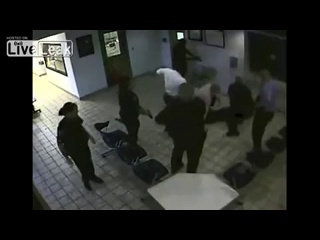

In [2]:
import cv2, os
from IPython.display import Image

def to_sec(t):
    parts = t.strip().split(":")
    if len(parts) == 2 and parts[0] and parts[1]:
        return int(parts[0])*60 + int(parts[1])
    return 0

# Шаг в секундах (0.5 = кадр каждые полсекунды)
STEP_SEC = 0.5

with open("timecodes.txt") as file:
    lines = [l.strip() for l in file if l.strip()]

for i in range(0, len(lines), 2):
    if i+1 >= len(lines): break
    cap = cv2.VideoCapture(f"videos/train/{lines[i]}")
    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps <= 0: fps = 30
    
    for frag in lines[i + 1].split("|"):
        if "-" not in frag: continue
        parts = frag.split("-")
        if len(parts) != 2: continue
        start, end = map(to_sec, parts)
        
        t = start
        while t <= end:
            frame_num = int(t * fps)
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
            ret, frame = cap.read()
            if ret:
                name = os.path.basename(lines[i]).rsplit(".", 1)[0]
                sec_str = f"{t:.1f}".replace(".", "_")
                cv2.imwrite(f"dataset/images/train/{name}_frame{sec_str}.jpg", frame)
            t += STEP_SEC
    cap.release()

display(Image(filename=f"dataset/images/train/{name}_frame{sec_str}.jpg"))

Далее последние 20 кадров переносим в папку для проверочной выборки.

In [3]:
import shutil
import math

def move_last_twenty_percent(source_dir, dest_dir):
    os.makedirs(dest_dir, exist_ok = True)
    
    # Получаем список всех файлов
    files = os.listdir(source_dir)
    
    # Вычисляем индекс, с которого нужно начать перенос
    total_files = len(files)
    start_index = math.floor(total_files * 0.8)
    
    files_to_move = files[start_index:]
    
    # Перемещаем файлы
    for file in files_to_move:
        src_path = os.path.join(source_dir, file)
        dest_path = os.path.join(dest_dir, file)
        shutil.move(src_path, dest_path)

move_last_twenty_percent('dataset/images/train', 'dataset/images/val')

train_images = os.listdir("dataset/images/train")
val_images = os.listdir("dataset/images/val")

print(f"Количество изображений в тренировочной выборке: {len(train_images)}")
print(f"Количество изображений в проверочной выборке: {len(val_images)}")

Количество изображений в тренировочной выборке: 479
Количество изображений в проверочной выборке: 120


При помощи аннотатора были получены метки с областями для каждого изображения и помещены в датасет, согласно документации YOLO, ведь именно эта модель и будет дообучаться на подготовленных данных. Метки областей также записаны в формате YOLO.

<h2>2. Обучение модели</h2>

Ниже происходит обучение модели.

In [4]:
from ultralytics import YOLO
import yaml

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import warnings
warnings.filterwarnings("ignore")

def create_config():
    config = {
        "path": "./dataset",
        "train": "images/train",
        "val": "images/train",
        "nc": 1,
        "names": ["conflict"]
    }
    with open("config.yaml", "w") as file:
        yaml.dump(config, file)

create_config()

model = YOLO("yolov8n.pt")
model.train(
    data = "config.yaml",
    epochs = 50,
    imgsz = 640,
    batch = 8,
    seed = 42,
    deterministic = True,
    single_cls = True
)

Ultralytics 8.4.67  Python-3.13.5 torch-2.12.0+cpu CPU (Intel Core i5-10300H 2.50GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=config.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001394C7D57F0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

<h2>3. Прогноз и оценка качества модели.</h2>

Теперь применим модель к тестовому видео и посмотрим результат.

In [5]:
# from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")

results = model("videos/test/Arrest042_x264.mp4", 
                conf = 0.5,
                save = True,
                save_dir='./')


WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/1590) C:\Users\admin\Documents\Conflict detection\videos\test\Arrest042_x264.mp4: 480x640 (no detections), 87.4ms
video 1/1 (frame 2/1590) C:\Users\admin\Documents\Conflict detection\videos\test\Arrest042_x264.mp4: 480x640 (no detections), 80.1ms
video 1/1 (frame 3/1590) C:\Users\admin\Documents\Conflict detection\videos\test\Arrest042_x264.mp4: 480x640 (no detections), 63.2ms
video 1/1 (frame 4/1590) C:\Users\admin\Documents\Conflict det

Полученное видео с результатом прогнозирования приложено в папке с этим ноутбуком на гугл диске. <br><br> 


Теперь проаналицируем процесс обучения модели и сделаем вывод о его качестве. Все эпохи обучения модели были автоматически сохранены в csv файл.

In [6]:
import pandas as pd

df = pd.read_csv("runs/detect/train/results.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   epoch                 50 non-null     int64  
 1   time                  50 non-null     float64
 2   train/box_loss        50 non-null     float64
 3   train/cls_loss        50 non-null     float64
 4   train/dfl_loss        50 non-null     float64
 5   metrics/precision(B)  50 non-null     float64
 6   metrics/recall(B)     50 non-null     float64
 7   metrics/mAP50(B)      50 non-null     float64
 8   metrics/mAP50-95(B)   50 non-null     float64
 9   val/box_loss          50 non-null     float64
 10  val/cls_loss          50 non-null     float64
 11  val/dfl_loss          50 non-null     float64
 12  lr/pg0                50 non-null     float64
 13  lr/pg1                50 non-null     float64
 14  lr/pg2                50 non-null     float64
dtypes: float64(14), int64(1)


Выведем график обучения модели.

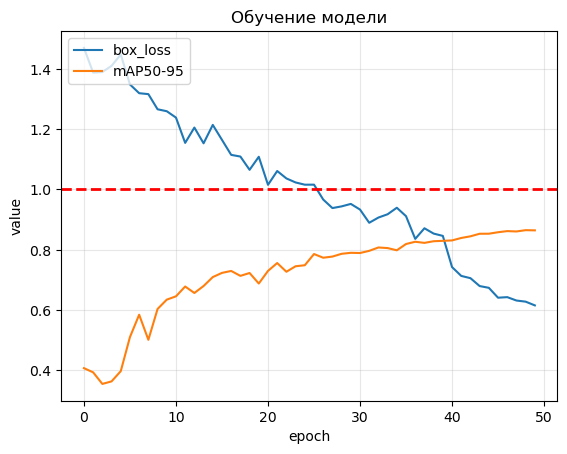

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt

# plt.clf()
plt.plot(df[["train/box_loss", "metrics/mAP50-95(B)"]])
plt.title("Обучение модели")
plt.ylabel('value')
plt.xlabel('epoch')
plt.grid(axis = "x", alpha = 0.3)
plt.grid(axis = "y", alpha = 0.3)
plt.axhline(1, color = "red", linestyle = "--", linewidth = 2,)
plt.legend(['box_loss', 'mAP50-95'], loc='upper left')
plt.show()

На графике показаны значения функции потерь, отвечающей за определение ошибки при определении координат рамки (чем меньше значение, тем лучше), а также значения метрики mAP50-95, которая комплексно оценивает как точность распознавания класса (в текущем случае класс всего один, так что этот момент особой роли не играет), так и аккуратность прорисовки ограничивающих рамок (чем выше значение, тем лучше). На графике видно, что модель под конец достигла значения mAP50-95 около 0.85, что говорит о том, что модель в почти в 85% случаев правильно расставляет рамки на проверочной выборке.